# 7. Tutorial 7

**Course:** Power Electronics Devices and Components

## 7.1. Optimum operating flux density from copper-loss / core-loss trade-off

This coding task studies the magnetic-design trade-off emphasized in the lecture:
$$P_{\mathrm{total}} = P_{\mathrm{core}} + P_{\mathrm{Cu}}$$

where increasing $B_{\mathrm{pk}}$ reduces turns and copper loss but increases core loss sharply.

### Fixed values for this tutorial
Let the operating peak flux density vary over:
$$B_{\mathrm{pk}} \in [0.05, 0.28]~\mathrm{T}$$

Use the following tutorial proxy equations:

$$P_{\mathrm{core}} \propto 18 \cdot B_{\mathrm{pk}}^{2.6} $$
and
$$P_{\mathrm{Cu}} \propto \frac{0.20}{B_{\mathrm{pk}}^2}$$

These expressions are chosen to reproduce the qualitative lecture behavior:
- higher $B_{\mathrm{pk}}$ $\Rightarrow$ fewer turns $\Rightarrow$ lower copper loss,
- higher $B_{\mathrm{pk}}$ $\Rightarrow$ much higher core loss.

### Student tasks
7.1.1 Import the required modules and define the $B_{\mathrm{pk}}$ range.

7.1.2 Create functions calc_Pcore(B), calc_Pcu(B) and calc_Ptotal(B) according the given equations.

7.1.3 Plot $P_{\mathrm{core}}$, $P_{\mathrm{Cu}}$, and $P_{\mathrm{total}}$ versus $B_{\mathrm{pk}}$.

7.1.4 Determine the approximate optimum $B_{\mathrm{pk}}$ that minimizes $P_{\mathrm{total}}$.

7.1.5 Mark on the plot the regions where the design is copper-loss dominated and core-loss dominated.

7.1.6 Explain why modern GaN/SiC converters often move the optimum toward lower $B_{\mathrm{pk}}$ than older low-frequency designs.


In [1]:
# Subtask 7.1.1 Import necessary modules and define the B_pk range.

import numpy as np
import matplotlib.pyplot as plt

B_pk = np.linspace(0.05, 0.28, 400)


In [2]:
# Subtask 7.1.2 Create functions calc_Pcore(B), calc_Pcu(B) and calc_Ptotal(B) according the given equations.

def calc_Pcore(B):
    return 18.0 * B**2.6

def calc_Pcu(B):
    return 0.20 / B**2

def calc_Ptotal(B):
    return calc_Pcore(B) + calc_Pcu(B)


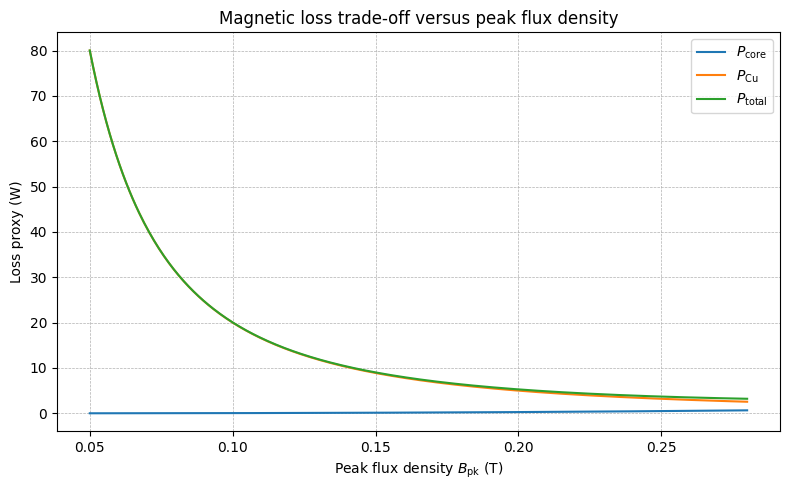

In [3]:
# Subtask 7.1.3 Plot P_core, P_Cu, and P_total versus B_pk.

P_core = calc_Pcore(B_pk)
P_cu = calc_Pcu(B_pk)
P_total = calc_Ptotal(B_pk)

plt.figure(figsize=(8, 5))
plt.plot(B_pk, P_core, label=r'$P_{\mathrm{core}}$')
plt.plot(B_pk, P_cu, label=r'$P_{\mathrm{Cu}}$')
plt.plot(B_pk, P_total, label=r'$P_{\mathrm{total}}$')
plt.xlabel(r'Peak flux density $B_{\mathrm{pk}}$ (T)')
plt.ylabel('Loss proxy (W)')
plt.title('Magnetic loss trade-off versus peak flux density')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
# Subtask 7.1.4 Determine the approximate optimum B_pk that minimizes P_total.

idx_min = np.argmin(P_total)
B_opt = B_pk[idx_min]
P_opt = P_total[idx_min]

print(f'Approximate optimum B_pk = {B_opt:.4f} T')
print(f'Minimum total loss proxy = {P_opt:.4f} W')


Approximate optimum B_pk = 0.2800 T
Minimum total loss proxy = 3.2085 W


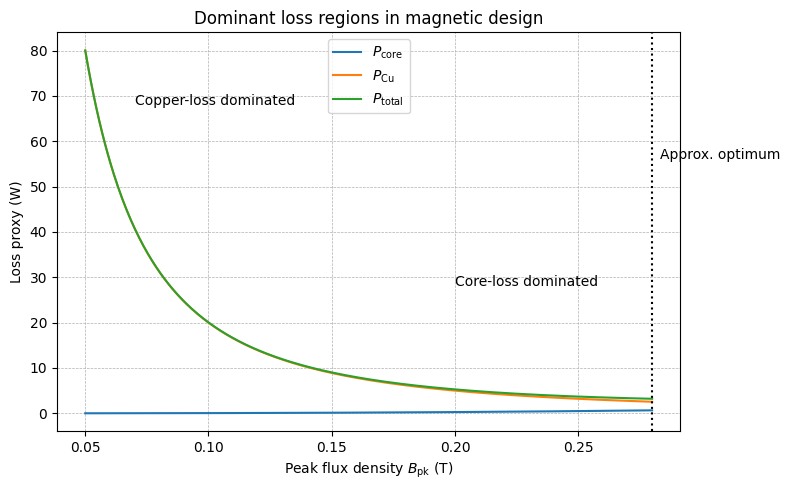

In [5]:
# Subtask 7.1.5 Mark on the plot the regions where the design is copper-loss dominated and core-loss dominated.

plt.figure(figsize=(8, 5))
plt.plot(B_pk, P_core, label=r'$P_{\mathrm{core}}$')
plt.plot(B_pk, P_cu, label=r'$P_{\mathrm{Cu}}$')
plt.plot(B_pk, P_total, label=r'$P_{\mathrm{total}}$')
plt.axvline(B_opt, color='black', linestyle=':')
plt.text(B_opt + 0.003, max(P_total)*0.7, 'Approx. optimum')
plt.text(0.07, max(P_total)*0.85, 'Copper-loss dominated')
plt.text(0.20, max(P_total)*0.35, 'Core-loss dominated')
plt.xlabel(r'Peak flux density $B_{\mathrm{pk}}$ (T)')
plt.ylabel('Loss proxy (W)')
plt.title('Dominant loss regions in magnetic design')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


**Subbtask 7.1.6** Explain why modern GaN/SiC converters often move the optimum toward lower $B_{\mathrm{pk}}$ than older low-frequency designs.

**Answer**<br>
With modern GaN/SiC converters a higher frequency can be used while similar switching frequency. So the magnetic component volume can be reduced. On the other hand the magnetic losses increases. A reduction can be reached by a reducing the magnetic flux density through he core, although the magnetic component volume cannot be reduced too much.

## 7.2. Skin depth, conductor thickness, and when round wire stops behaving like DC copper

This coding task studies the relation between skin depth and conductor dimensions.

### Fixed values for this tutorial
Use 
- copper resistivity: $\rho = 1.72\times 10^{-8}~\Omega\cdot \mathrm{m}$.
- permeability: $\mu = \mu_0 = 4\pi\times 10^{-7}~\mathrm{H/m}$.
- frequency range: $f = 1~\mathrm{kHz} \text{ to } 5~\mathrm{MHz}$.

Compare against these conductor dimensions:
- round wire radius $r = 0.25~\mathrm{mm}$,
- round wire radius $r = 0.50~\mathrm{mm}$,
- foil thickness $t = 0.10~\mathrm{mm}$,
- PCB copper thickness $t = 70~\mu\mathrm{m}$.

Use the lecture relation: $\delta = \sqrt{\frac{2\rho}{\omega \mu}}$

### Student tasks
7.2.1 Import the required modules and define the constant values.

7.2.2 Create a function `calc_skin_depth(freq)` for the skin depth $\delta(f)$.

7.2.3 Plot $\delta(f)$ from $1~\mathrm{kHz}$ to $5~\mathrm{MHz}$.

7.2.4 Plot the ratios $\frac{r}{\delta}$ and $\frac{t}{\delta}$ for the conductor options.

7.2.5 Indicate on the graph where each conductor begins to experience strong skin-effect limitation.

7.2.6 Based on the plots, discuss which conductor type becomes more attractive as frequency moves into the hundreds of kHz and MHz range.

7.2.7 Explain why proximity effect can still make the final AC resistance worse than what skin depth alone predicts.


In [6]:
# Subtask 7.2.1 Import the required modules and define the constant values.

rho = 1.72e-8
mu0 = 4*np.pi*1e-7

f = np.logspace(3, np.log10(5e6), 500)
omega = 2*np.pi*f

r1 = 0.25e-3
r2 = 0.50e-3
t_foil = 0.10e-3
t_pcb = 70e-6


In [7]:
# Subtask 7.2.2 Create a function calc_skin_depth(freq) for the skin depth delta(f).

def calc_skin_depth(freq):
    omega = 2*np.pi*freq
    return np.sqrt(2*rho/(omega*mu0))

# Subtask 7.2.3 Create a function onset_frequency(dim) calculation of frequency, which fulfills the condition dim/delta >= 1.0.
def onset_frequency(dim):
    # Get the first value, which fulfills the condition
    idx = np.argmax(dim / delta >= 1.0)
    return f[idx]

delta = calc_skin_depth(f)


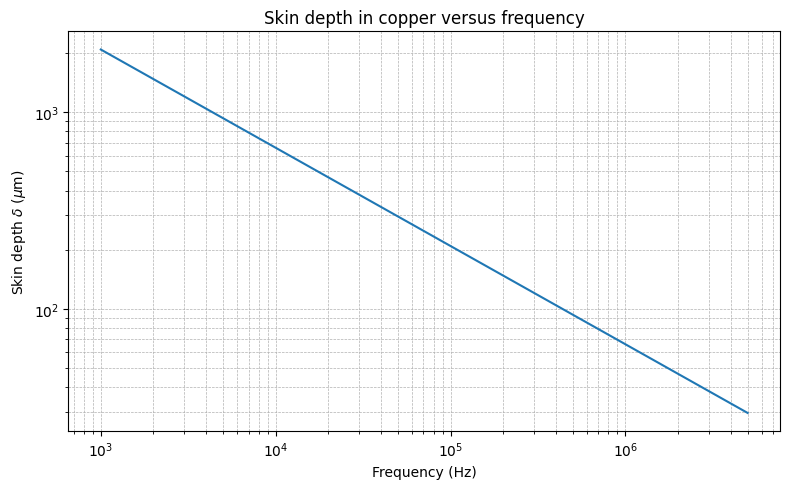

In [8]:
# Subtask 7.2.4 Plot delta(f) from 1 kHz to 5 MHz.

plt.figure(figsize=(8,5))
plt.loglog(f, delta*1e6)
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'Skin depth $\delta$ ($\mu$m)')
plt.title('Skin depth in copper versus frequency')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


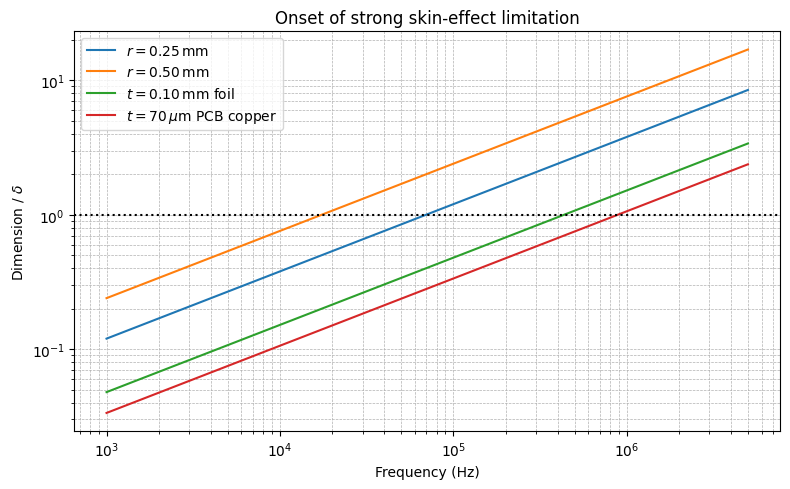

In [9]:
# Subtask 7.2.5 Plot the ratios r/delta and t/delta for the conductor options.

ratio_r1 = r1 / delta
ratio_r2 = r2 / delta
ratio_foil = t_foil / delta
ratio_pcb = t_pcb / delta

plt.figure(figsize=(8,5))
plt.loglog(f, ratio_r1, label=r'$r=0.25\,\mathrm{mm}$')
plt.loglog(f, ratio_r2, label=r'$r=0.50\,\mathrm{mm}$')
plt.loglog(f, ratio_foil, label=r'$t=0.10\,\mathrm{mm}$ foil')
plt.loglog(f, ratio_pcb, label=r'$t=70\,\mu\mathrm{m}$ PCB copper')
plt.axhline(1.0, linestyle=':', color='black')
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'Dimension / $\delta$')
plt.title('Onset of strong skin-effect limitation')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
# Subtask 7.2.6 Indicate on the graph where each conductor begins to experience strong skin-effect limitation.
# Subtask 7.2.7 Based on the plots, discuss which conductor type becomes more attractive as frequency moves into the hundreds of kHz and MHz range.

for name, dim in [('round wire r=0.25 mm', r1), ('round wire r=0.50 mm', r2), ('foil t=0.10 mm', t_foil), ('PCB copper t=70 um', t_pcb)]:
    print(f'{name}: strong skin-effect onset around {onset_frequency(dim):.0f} Hz')

print('As frequency rises into the hundreds of kHz and MHz range, thinner foil, PCB copper, or litz-like conductors become increasingly attractive.')


round wire r=0.25 mm: strong skin-effect onset around 70110 Hz
round wire r=0.50 mm: strong skin-effect onset around 17593 Hz
foil t=0.10 mm: strong skin-effect onset around 442953 Hz
PCB copper t=70 um: strong skin-effect onset around 891827 Hz
As frequency rises into the hundreds of kHz and MHz range, thinner foil, PCB copper, or litz-like conductors become increasingly attractive.


**Subbtask 7.2.8** Explanation of proximity effect.

**Answer**<br>
Skin depth alone describes self-distribution of current in one conductor.
In windings, nearby conductors create non-uniform magnetic fields that crowd current further, increasing AC resistance beyond the skin-effect prediction. This is the proximity effect.